# Delete Later: Trace Feature Tables Overview

In [3]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)


In [4]:
RUN_DIR = Path(r"C:\Users\mikol\OneDrive\Pulpit\Praca Magisterska\data\20260601-184756_Qwen-Qwen2.5-3B-Instruct_csqa_trace_feature_tables")
with open(RUN_DIR / 'run_config.json', 'r', encoding='utf-8') as f:
    run_config = json.load(f)

examples_df = pd.read_parquet(RUN_DIR / 'examples.parquet')
layerwise_df = pd.read_parquet(RUN_DIR / 'layerwise_readouts.parquet')
headwise_df = pd.read_parquet(RUN_DIR / 'headwise_attention_entropy.parquet')
tuned_lens_history_df = pd.read_parquet(RUN_DIR / 'tuned_lens_training_history.parquet')

print(run_config)
print('examples:', examples_df.shape)
print('layerwise:', layerwise_df.shape)
print('headwise:', headwise_df.shape)


{'model_id': 'Qwen/Qwen2.5-3B-Instruct', 'max_seq_len': 384, 'seed': 42, 'train_limit': None, 'validation_limit': None, 'num_layers': 36, 'hidden_size': 2048, 'extract_batch_size': 4, 'attention_batch_size': 1, 'readout_batch_size': 64, 'tuned_lens_batch_size': 64, 'tuned_lens_epochs': 2, 'tuned_lens_lr': 0.001, 'tuned_lens_weight_decay': 1e-05, 'layerwise_table': 'layerwise_readouts.parquet', 'headwise_table': 'headwise_attention_entropy.parquet'}
examples: (10962, 8)
layerwise: (789264, 12)
headwise: (6314112, 5)


## Sanity

In [5]:
display(examples_df.head(3))
display(layerwise_df.head(3))
display(headwise_df.head(3))

print('split counts:', examples_df['split'].value_counts().to_dict())
print('readout counts:', layerwise_df['readout_method'].value_counts().to_dict())
print('layer range:', int(layerwise_df['layer_number'].min()), int(layerwise_df['layer_number'].max()))
print('head range:', int(headwise_df['head_number'].min()), int(headwise_df['head_number'].max()))


,example_id,split,text,answerKey,correct_idx,prompt_len_chars,prompt_token_count,decision_pos
0,42ed410d54eae473eb4578d8550259ed,train,Q: The sanctions against the school were a pun...,A,0,200,51,50
1,a7059f15c9a41e642c05358ee3bfdad5,train,Q: Sammy wanted to go to where the people were...,B,1,157,46,50
2,ae67f1af6b3e31ab97be57aa2519b565,train,Q: To locate a choker not located in a jewelry...,A,0,166,49,50


,example_id,split,layer_number,readout_method,true_choice_idx,best_non_choice_token_id,best_non_choice_logit,logit_A,logit_B,logit_C,logit_D,logit_E
0,42ed410d54eae473eb4578d8550259ed,train,1,direct_readout,0,133532,13.6250,1.656250,2.703125,0.212891,-1.617188,3.421875
1,a7059f15c9a41e642c05358ee3bfdad5,train,1,direct_readout,1,133532,13.5000,1.976562,2.953125,0.210938,-1.351562,3.390625
2,ae67f1af6b3e31ab97be57aa2519b565,train,1,direct_readout,0,94283,13.3125,1.781250,2.421875,-0.028809,-1.781250,3.312500


,example_id,split,layer_number,head_number,head_renyi2_entropy_normalized
0,42ed410d54eae473eb4578d8550259ed,train,1,1,0.361484
1,42ed410d54eae473eb4578d8550259ed,train,1,2,0.224091
2,42ed410d54eae473eb4578d8550259ed,train,1,3,0.178873


split counts: {'train': 9741, 'validation': 1221}
readout counts: {'direct_readout': 394632, 'tuned_lens': 394632}
layer range: 1 36
head range: 1 16


## Derive Layerwise Features

In [6]:
def add_choice_derived_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    choice_logits = out[['logit_A', 'logit_B', 'logit_C', 'logit_D', 'logit_E']].to_numpy(dtype=np.float32)
    shifted = choice_logits - choice_logits.max(axis=1, keepdims=True)
    exp = np.exp(shifted)
    probs = exp / exp.sum(axis=1, keepdims=True)
    log_probs = np.log(np.clip(probs, 1e-12, None))

    sorted_logits = np.sort(choice_logits, axis=1)[:, ::-1]
    sorted_probs = np.sort(probs, axis=1)[:, ::-1]
    pred_idx = np.argmax(choice_logits, axis=1)
    rows = np.arange(choice_logits.shape[0])
    true_idx = out['true_choice_idx'].to_numpy(dtype=np.int64)

    entropy = -(probs * log_probs).sum(axis=1)
    surprisal = -log_probs
    varentropy = (probs * (surprisal - entropy[:, None]) ** 2).sum(axis=1)
    true_prob = probs[rows, true_idx]
    true_logit = choice_logits[rows, true_idx]
    true_rank = 1 + (choice_logits > true_logit[:, None]).sum(axis=1)

    masked = choice_logits.copy()
    masked[rows, true_idx] = -np.inf
    best_other_true = masked.max(axis=1)

    out['predicted_choice_idx'] = pred_idx
    out['is_correct'] = pred_idx == true_idx
    out['answer_choice_entropy'] = entropy
    out['answer_choice_entropy_normalized'] = entropy / math.log(5)
    out['choice_varentropy'] = varentropy
    out['choice_top1_probability'] = sorted_probs[:, 0]
    out['answer_choice_top1_top2_logit_gap'] = sorted_logits[:, 0] - sorted_logits[:, 1]
    out['best_choice_minus_best_non_choice_logit'] = choice_logits.max(axis=1) - out['best_non_choice_logit'].to_numpy(dtype=np.float32)
    out['true_answer_probability_within_choices'] = true_prob
    out['true_answer_rank_within_choices'] = true_rank
    out['true_answer_logit_minus_best_other_choice_logit'] = true_logit - best_other_true
    return out

layerwise_feat_df = add_choice_derived_features(layerwise_df)

final_layer = int(layerwise_feat_df['layer_number'].max())
final_direct_df = (
    layerwise_feat_df.loc[
        layerwise_feat_df['layer_number'].eq(final_layer) & layerwise_feat_df['readout_method'].eq('direct_readout'),
        ['example_id', 'split', 'is_correct']
    ]
    .rename(columns={'is_correct': 'final_is_correct'})
)

layerwise_feat_df = layerwise_feat_df.merge(final_direct_df, on=['example_id', 'split'], how='left', validate='many_to_one')
layerwise_feat_df['final_error'] = (~layerwise_feat_df['final_is_correct']).astype(int)

headwise_feat_df = headwise_df.merge(final_direct_df, on=['example_id', 'split'], how='left', validate='many_to_one')
headwise_feat_df['final_error'] = (~headwise_feat_df['final_is_correct']).astype(int)

print(layerwise_feat_df.shape)
print(headwise_feat_df.shape)


(789264, 25)
(6314112, 7)


## Basic Outcome Summary

In [7]:
outcome_summary = (
    final_direct_df.groupby('split', as_index=False)
    .agg(
        n_examples=('example_id', 'count'),
        accuracy=('final_is_correct', 'mean')
    )
)
outcome_summary['error_rate'] = 1.0 - outcome_summary['accuracy']
display(outcome_summary)


,split,n_examples,accuracy,error_rate
0,train,9741,0.774458,0.225542
1,validation,1221,0.802621,0.197379


## Tuned Lens Training

,layer_number,epoch,mean_kl_loss
0,1,1,2.596569
1,1,2,1.768897
2,2,1,2.731429
3,2,2,1.845535
4,3,1,2.493250
...,...,...,...
65,33,2,0.776845
66,34,1,1.913093
67,34,2,0.817047
68,35,1,3.187812


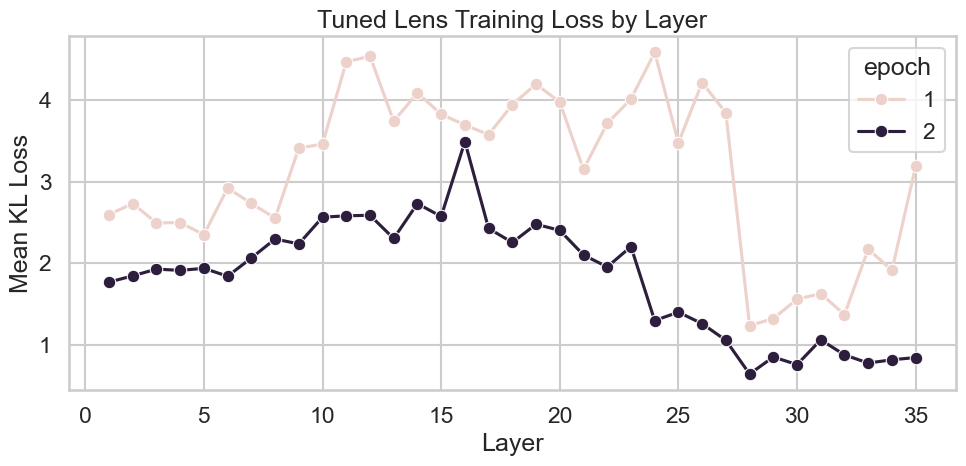

In [8]:
display(tuned_lens_history_df)

plt.figure(figsize=(10, 5))
sns.lineplot(data=tuned_lens_history_df, x='layer_number', y='mean_kl_loss', hue='epoch', marker='o')
plt.title('Tuned Lens Training Loss by Layer')
plt.xlabel('Layer')
plt.ylabel('Mean KL Loss')
plt.tight_layout()
plt.show()


## Final-Layer Histograms on Validation

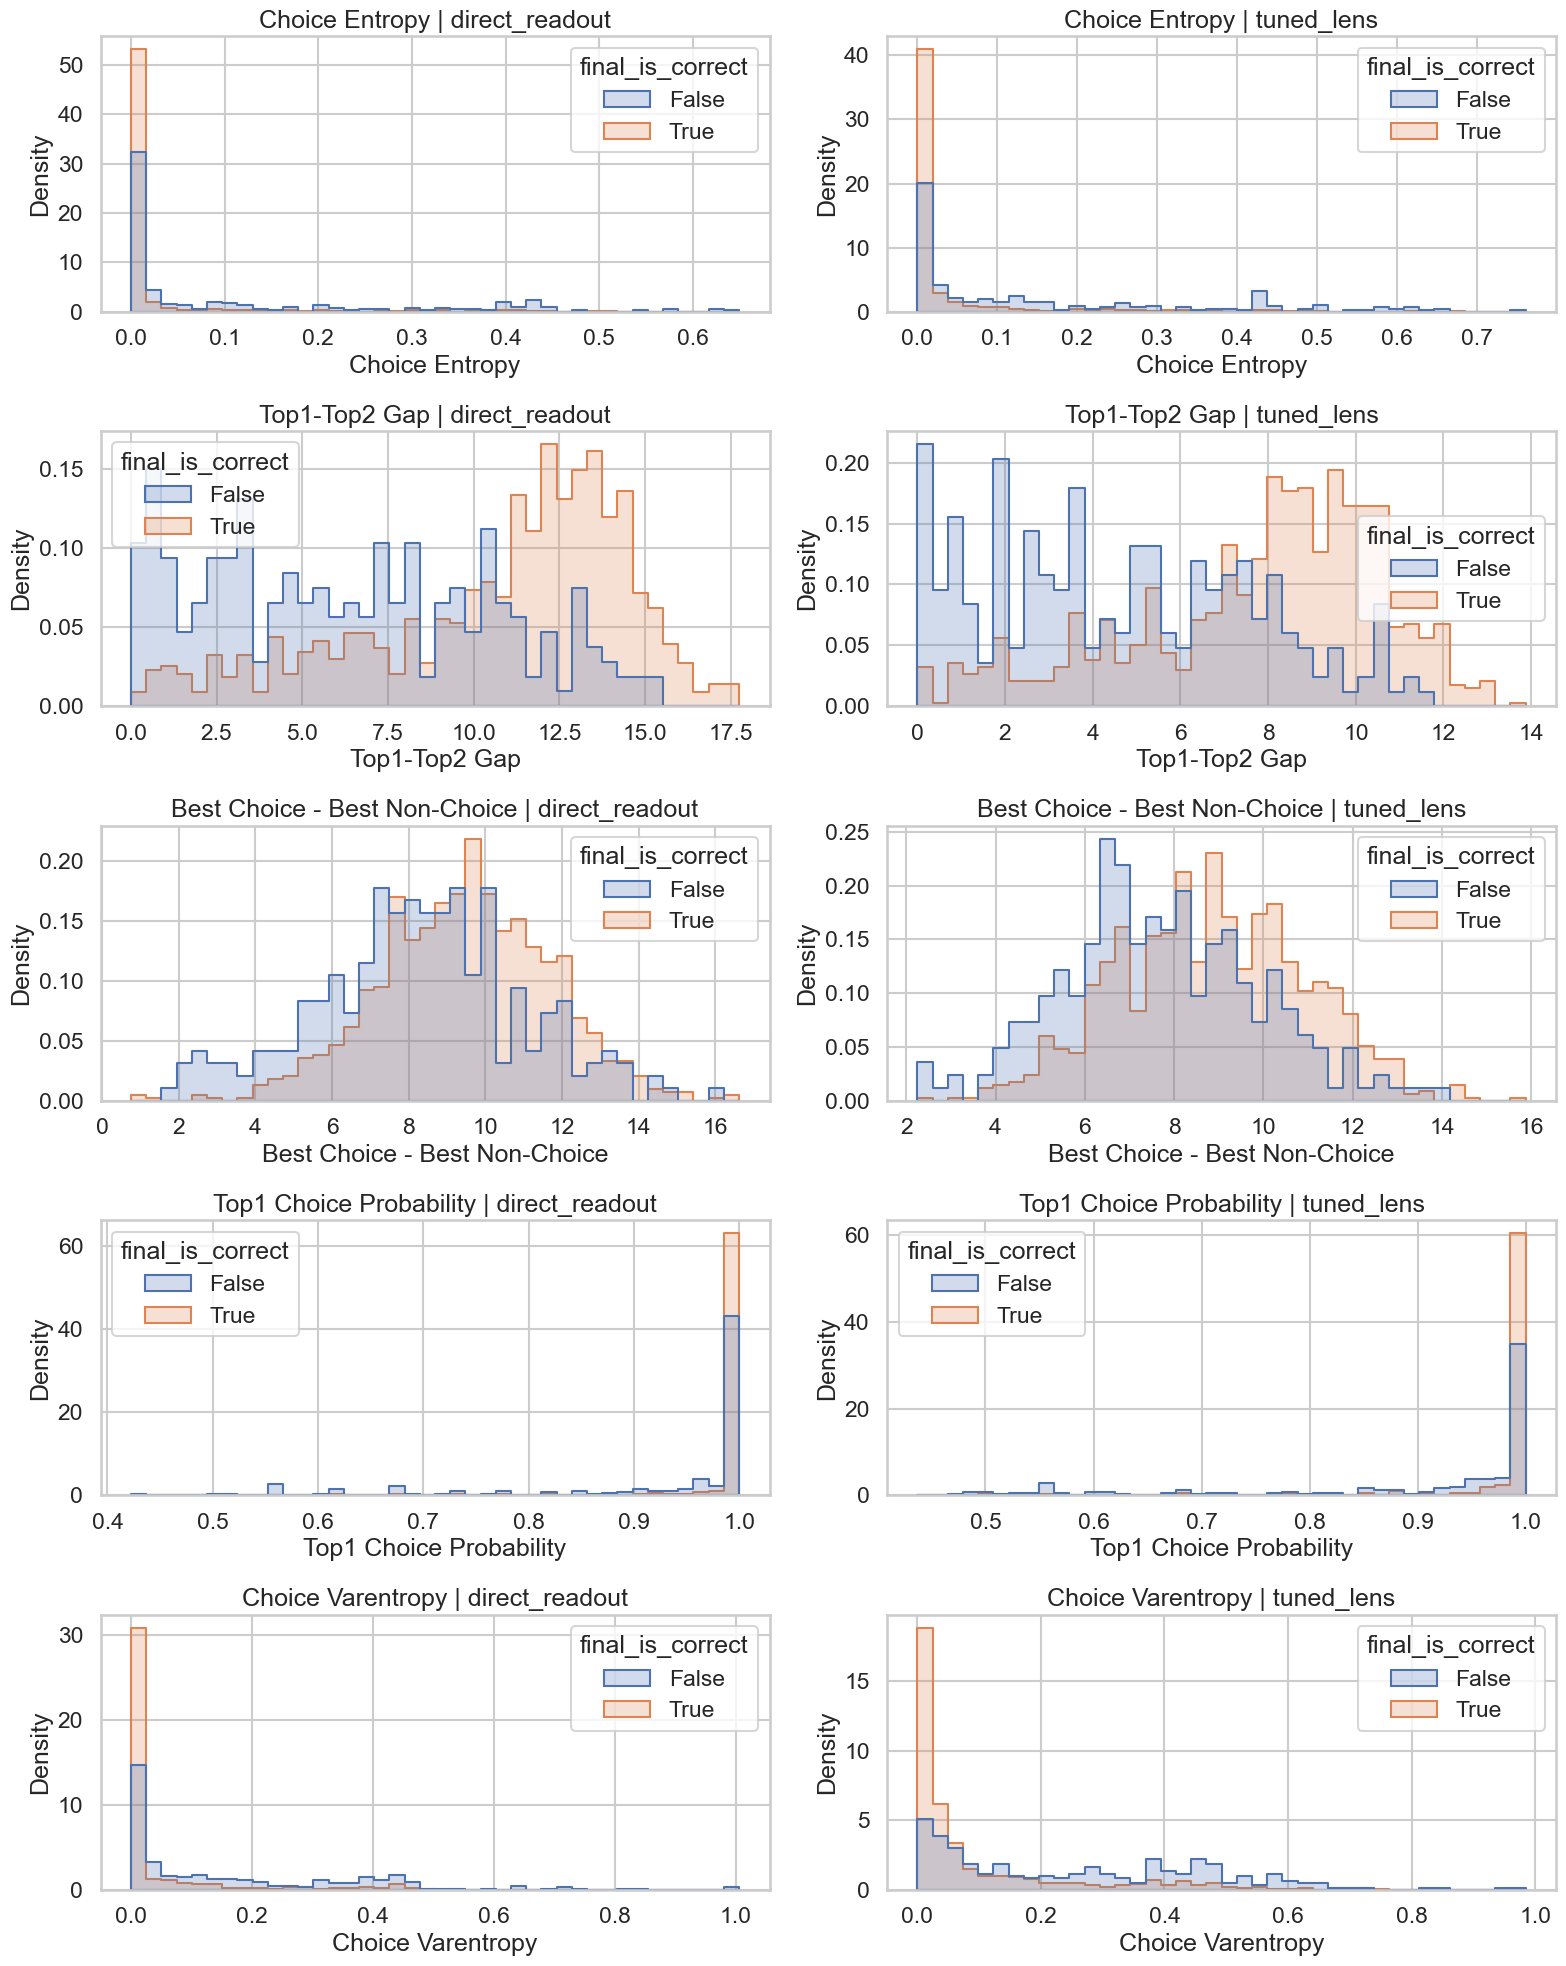

In [9]:
validation_final_df = layerwise_feat_df.loc[layerwise_feat_df['split'].eq('validation') & layerwise_feat_df['layer_number'].eq(final_layer)].copy()

feature_specs = [
    ('answer_choice_entropy_normalized', 'Choice Entropy'),
    ('answer_choice_top1_top2_logit_gap', 'Top1-Top2 Gap'),
    ('best_choice_minus_best_non_choice_logit', 'Best Choice - Best Non-Choice'),
    ('choice_top1_probability', 'Top1 Choice Probability'),
    ('choice_varentropy', 'Choice Varentropy'),
]

fig, axes = plt.subplots(len(feature_specs), 2, figsize=(16, 4 * len(feature_specs)), sharey=False)
for row_idx, (feature, title) in enumerate(feature_specs):
    for col_idx, method in enumerate(['direct_readout', 'tuned_lens']):
        ax = axes[row_idx, col_idx]
        part = validation_final_df.loc[validation_final_df['readout_method'].eq(method)]
        sns.histplot(
            data=part,
            x=feature,
            hue='final_is_correct',
            stat='density',
            common_norm=False,
            bins=40,
            element='step',
            ax=ax,
        )
        ax.set_title(f'{title} | {method}')
        ax.set_xlabel(title)
plt.tight_layout()
plt.show()


## Layer Curves by Final Correctness

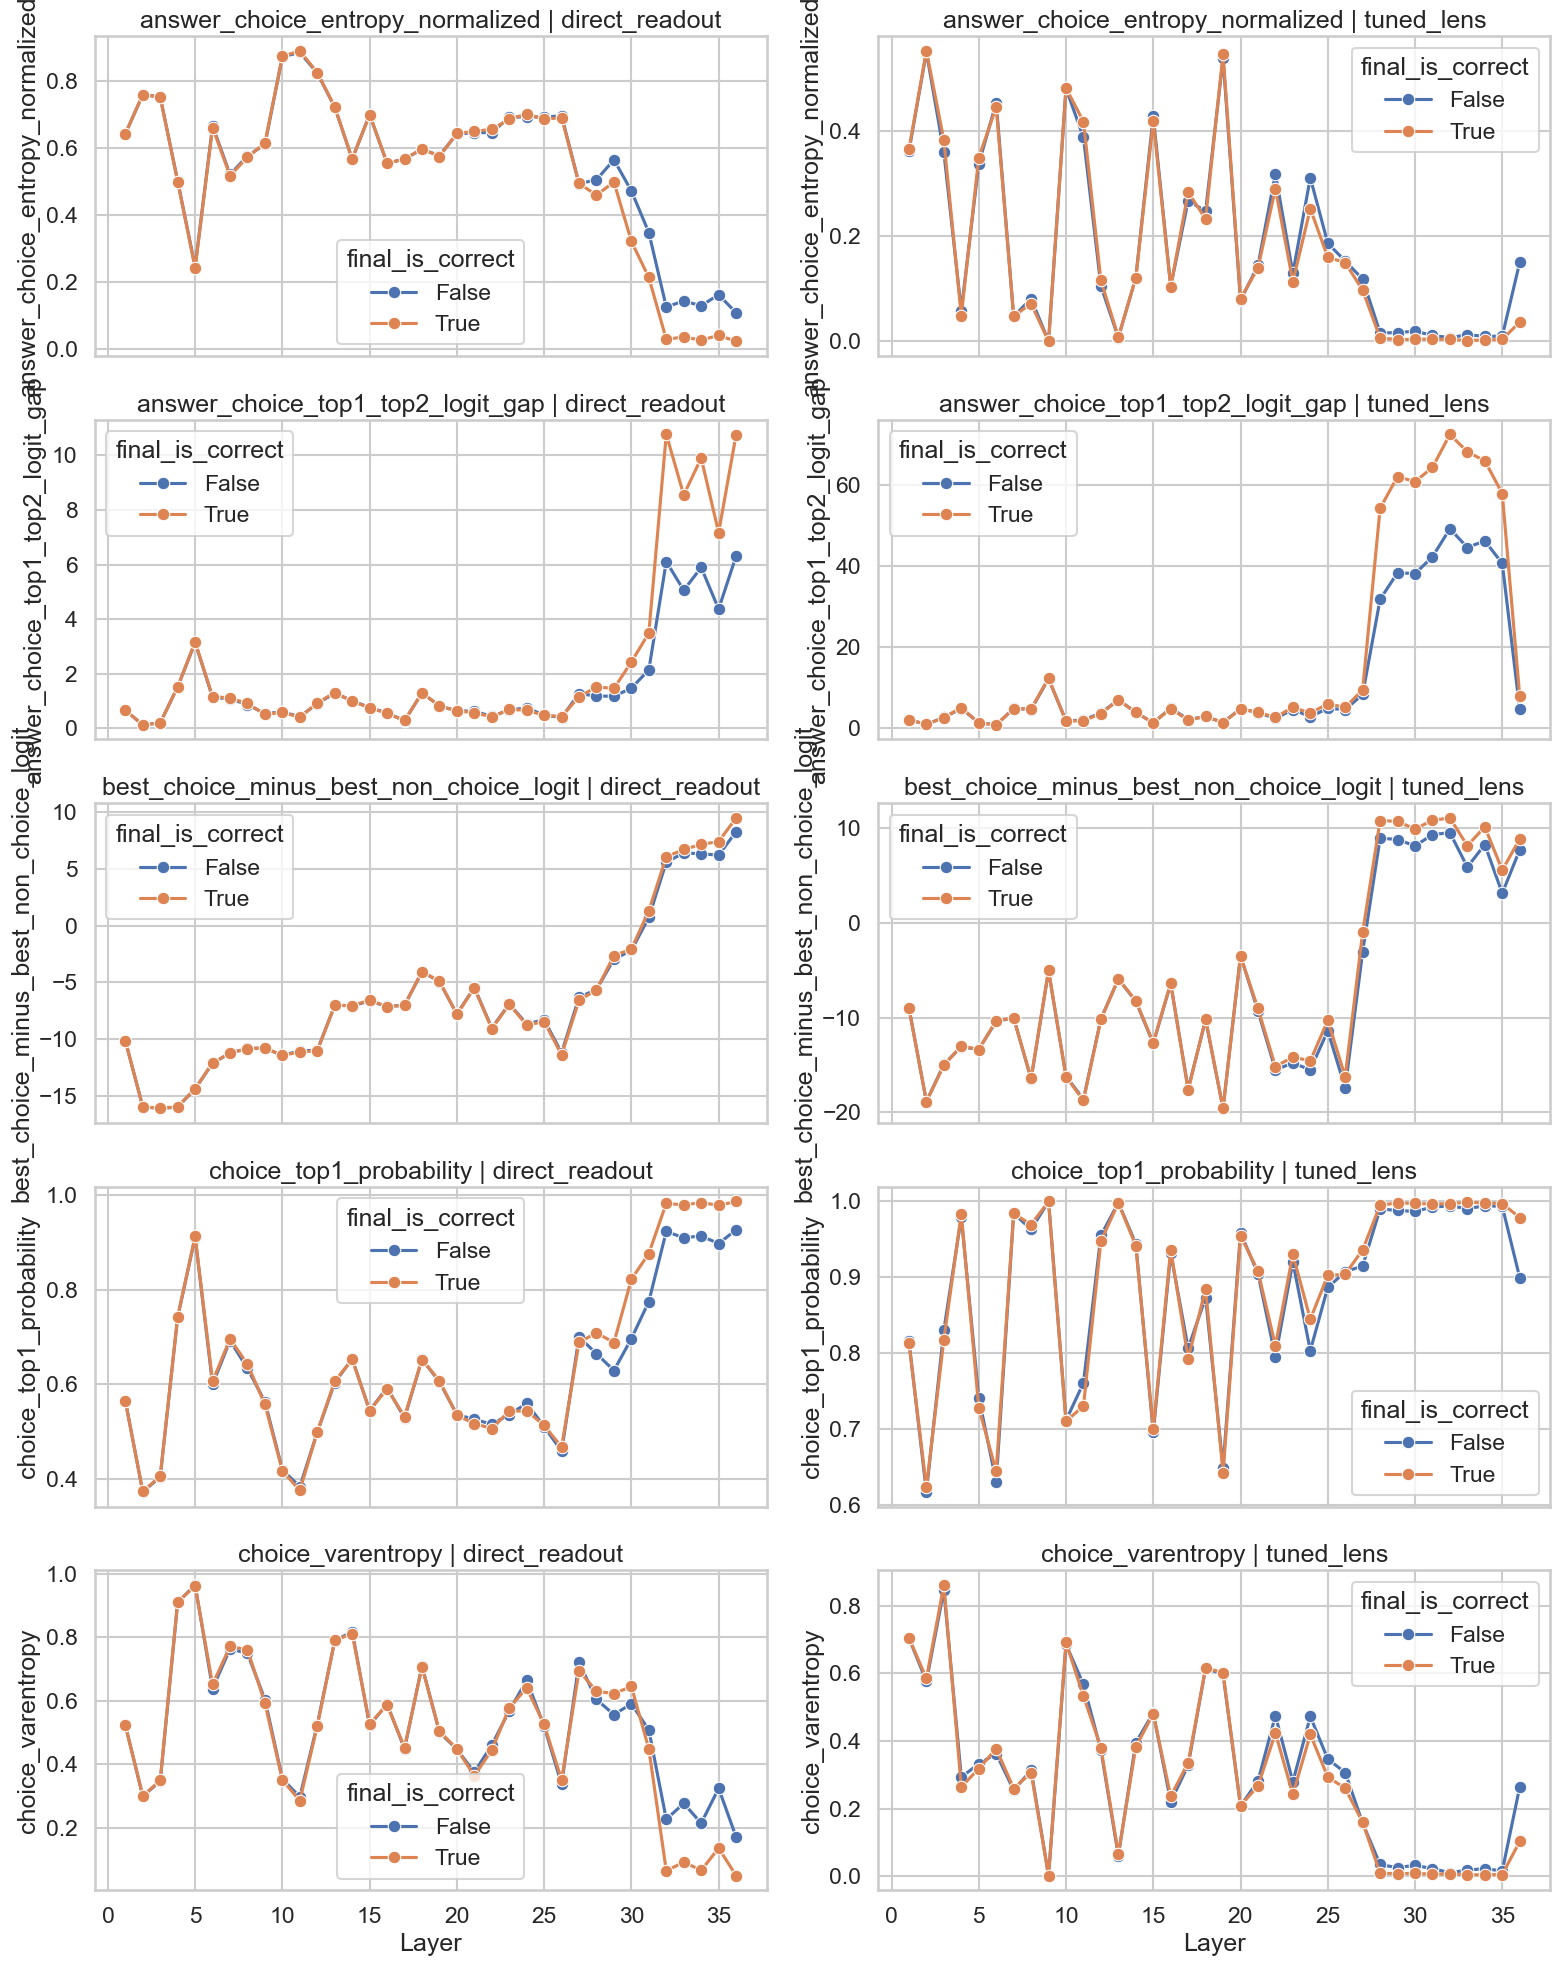

In [10]:
curve_features = [
    'answer_choice_entropy_normalized',
    'answer_choice_top1_top2_logit_gap',
    'best_choice_minus_best_non_choice_logit',
    'choice_top1_probability',
    'choice_varentropy',
]

curve_df = layerwise_feat_df.loc[layerwise_feat_df['split'].eq('validation')].copy()

fig, axes = plt.subplots(len(curve_features), 2, figsize=(16, 4 * len(curve_features)), sharex=True)
for row_idx, feature in enumerate(curve_features):
    for col_idx, method in enumerate(['direct_readout', 'tuned_lens']):
        ax = axes[row_idx, col_idx]
        part = curve_df.loc[curve_df['readout_method'].eq(method)]
        summary = (
            part.groupby(['layer_number', 'final_is_correct'], as_index=False)[feature]
            .mean()
        )
        sns.lineplot(data=summary, x='layer_number', y=feature, hue='final_is_correct', marker='o', ax=ax)
        ax.set_title(f'{feature} | {method}')
        ax.set_xlabel('Layer')
plt.tight_layout()
plt.show()


## Layerwise Predictive Strength

In [11]:
def feature_auc_table(df: pd.DataFrame, features: list[tuple[str, float]]) -> pd.DataFrame:
    rows = []
    for (method, layer_number), part in df.groupby(['readout_method', 'layer_number']):
        y = part['final_error'].to_numpy(dtype=int)
        for feature_name, sign in features:
            score = sign * part[feature_name].to_numpy(dtype=float)
            rows.append({
                'readout_method': method,
                'layer_number': int(layer_number),
                'feature': feature_name,
                'roc_auc_error': float(roc_auc_score(y, score)),
                'pr_auc_error': float(average_precision_score(y, score)),
            })
    return pd.DataFrame(rows)

auc_features = [
    ('answer_choice_entropy_normalized', 1.0),
    ('answer_choice_top1_top2_logit_gap', -1.0),
    ('best_choice_minus_best_non_choice_logit', -1.0),
    ('choice_top1_probability', -1.0),
    ('choice_varentropy', 1.0),
]

layer_auc_df = feature_auc_table(layerwise_feat_df.loc[layerwise_feat_df['split'].eq('validation')], auc_features)
display(layer_auc_df.sort_values(['pr_auc_error', 'roc_auc_error'], ascending=False).head(20).round(4))


,readout_method,layer_number,feature,roc_auc_error,pr_auc_error
170,direct_readout,35,answer_choice_entropy_normalized,0.7791,0.4732
178,direct_readout,36,choice_top1_probability,0.7820,0.4728
175,direct_readout,36,answer_choice_entropy_normalized,0.7820,0.4713
165,direct_readout,34,answer_choice_entropy_normalized,0.7735,0.4687
355,tuned_lens,36,answer_choice_entropy_normalized,0.7766,0.4663
168,direct_readout,34,choice_top1_probability,0.7739,0.4654
173,direct_readout,35,choice_top1_probability,0.7784,0.4642
176,direct_readout,36,answer_choice_top1_top2_logit_gap,0.7829,0.4617
171,direct_readout,35,answer_choice_top1_top2_logit_gap,0.7790,0.4554
358,tuned_lens,36,choice_top1_probability,0.7763,0.4524


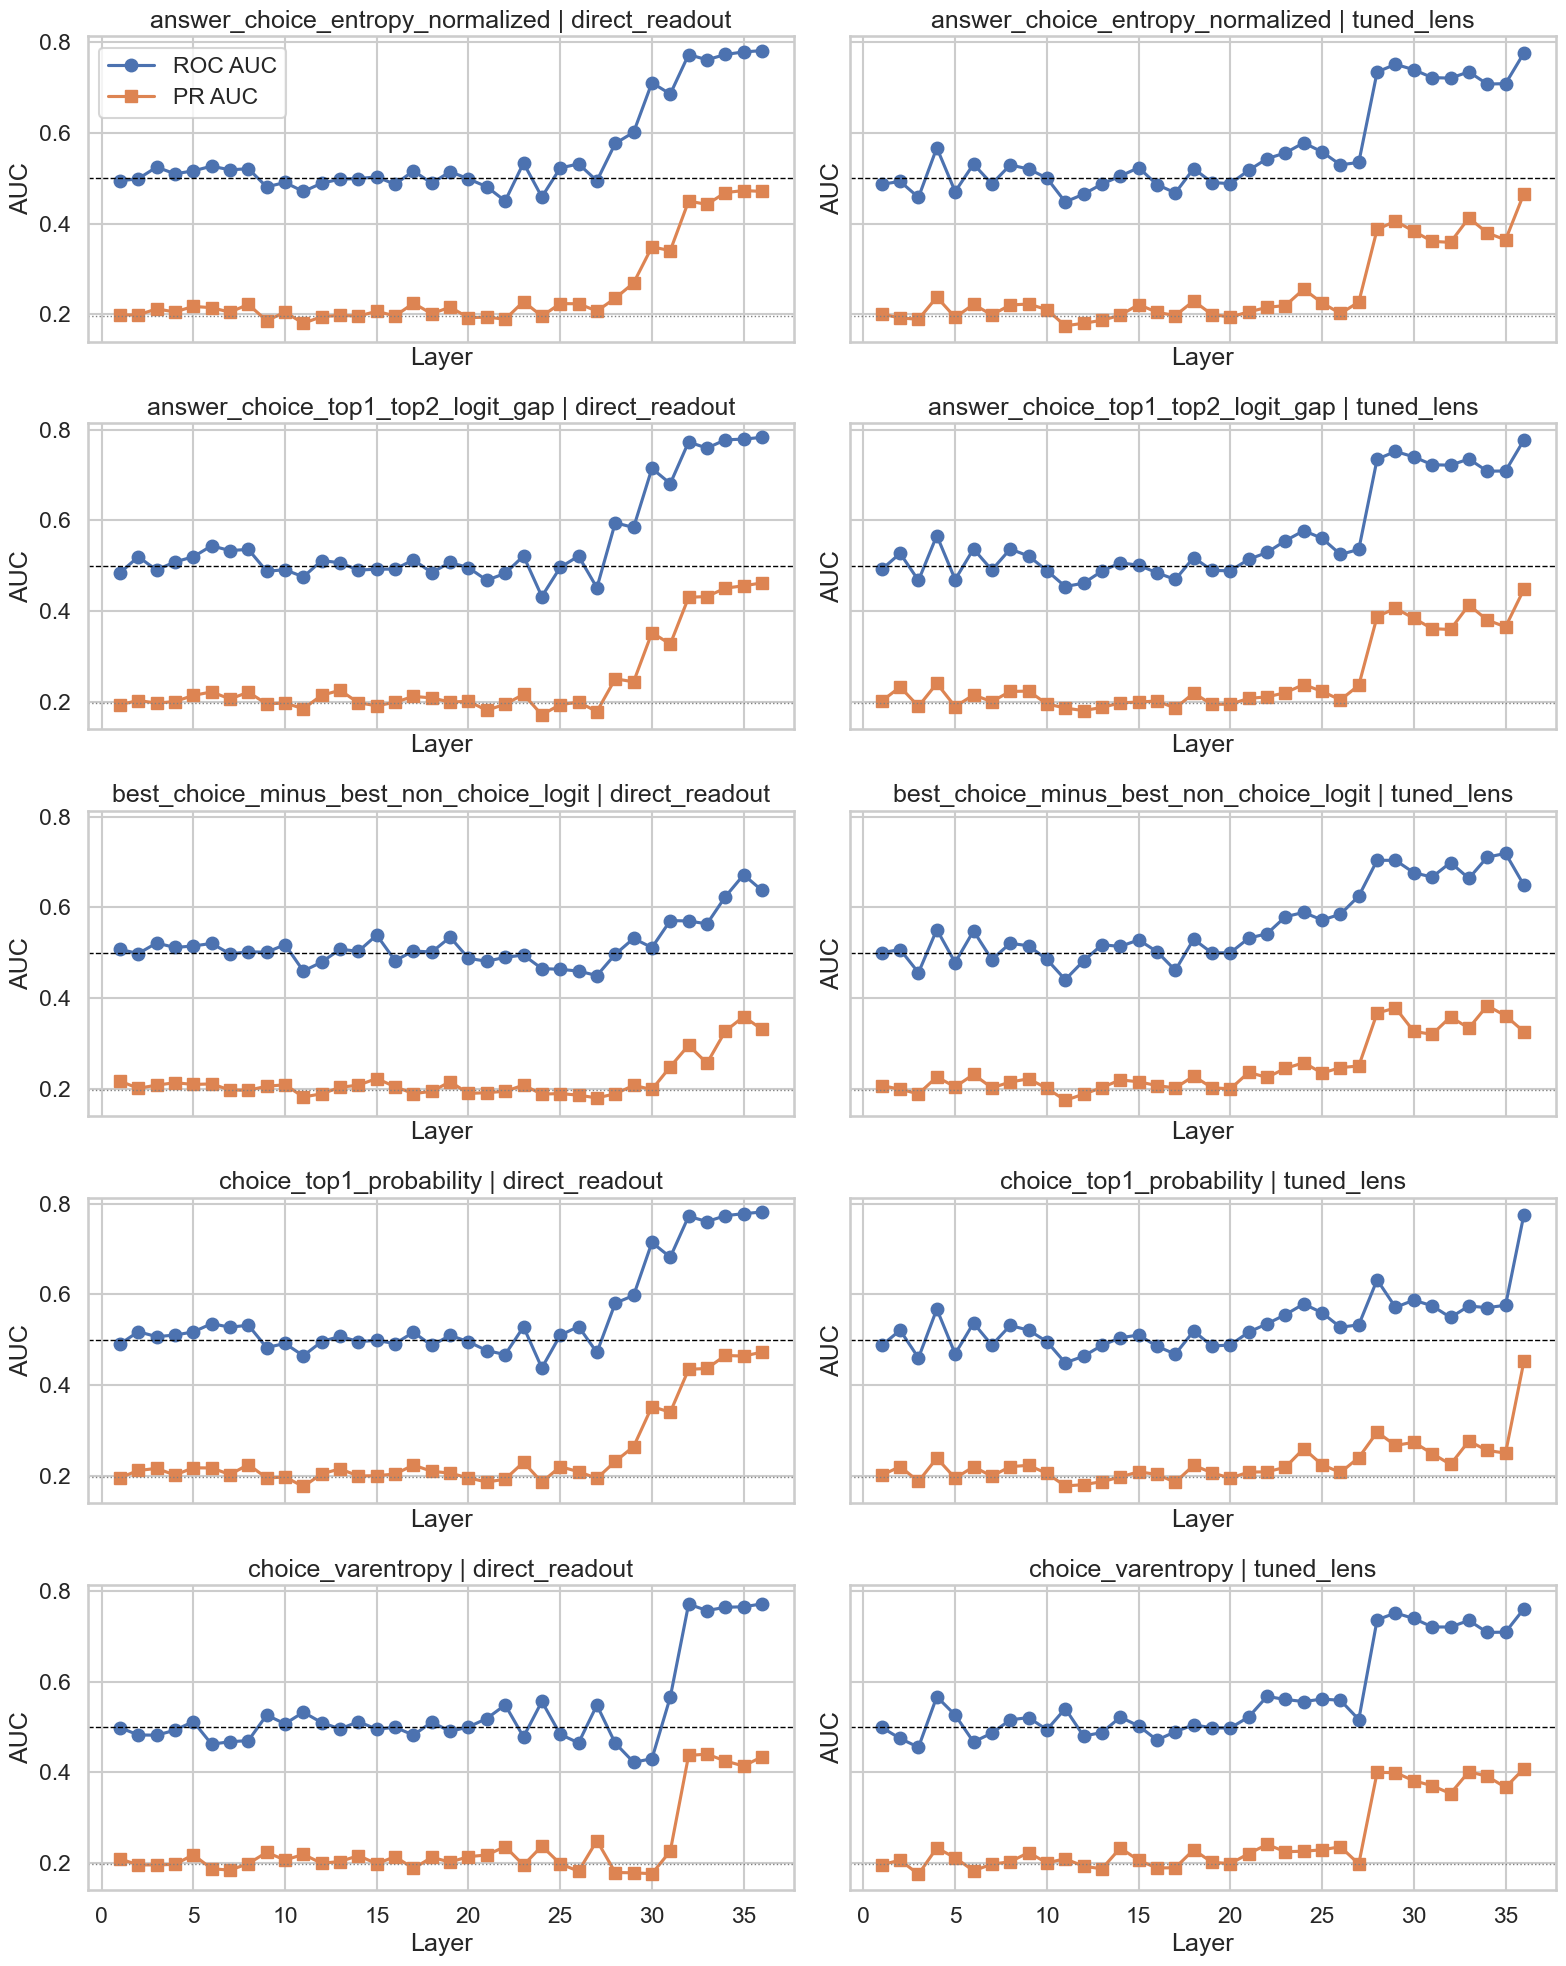

In [12]:
fig, axes = plt.subplots(len(auc_features), 2, figsize=(16, 4 * len(auc_features)), sharex=True, sharey=True)
error_rate = float(layerwise_feat_df.loc[layerwise_feat_df['split'].eq('validation'), 'final_error'].mean())

for row_idx, (feature_name, _) in enumerate(auc_features):
    for col_idx, method in enumerate(['direct_readout', 'tuned_lens']):
        ax = axes[row_idx, col_idx]
        part = layer_auc_df.loc[layer_auc_df['feature'].eq(feature_name) & layer_auc_df['readout_method'].eq(method)].sort_values('layer_number')
        ax.plot(part['layer_number'], part['roc_auc_error'], marker='o', label='ROC AUC')
        ax.plot(part['layer_number'], part['pr_auc_error'], marker='s', label='PR AUC')
        ax.axhline(0.5, color='black', linestyle='--', linewidth=1)
        ax.axhline(error_rate, color='gray', linestyle=':', linewidth=1)
        ax.set_title(f'{feature_name} | {method}')
        ax.set_xlabel('Layer')
        ax.set_ylabel('AUC')
        if row_idx == 0 and col_idx == 0:
            ax.legend()
plt.tight_layout()
plt.show()


## Final-Layer Summary Table

In [13]:
final_summary = (
    validation_final_df.groupby(['readout_method'], as_index=False)
    .agg(
        accuracy=('is_correct', 'mean'),
        entropy_mean=('answer_choice_entropy_normalized', 'mean'),
        gap_mean=('answer_choice_top1_top2_logit_gap', 'mean'),
        margin_mean=('best_choice_minus_best_non_choice_logit', 'mean'),
        msp_mean=('choice_top1_probability', 'mean'),
        varentropy_mean=('choice_varentropy', 'mean'),
    )
)
final_summary['error_rate'] = 1.0 - final_summary['accuracy']
display(final_summary.round(4))


,readout_method,accuracy,entropy_mean,gap_mean,margin_mean,msp_mean,varentropy_mean,error_rate
0,direct_readout,0.8026,0.0393,9.8771,9.2439,0.9747,0.0738,0.1974
1,tuned_lens,0.8010,0.0593,7.1616,8.6433,0.9631,0.1344,0.1990


## Headwise Attention Entropy: Quick Look

,final_is_correct,mean_head_renyi2_entropy
0,False,0.3171
1,True,0.3157


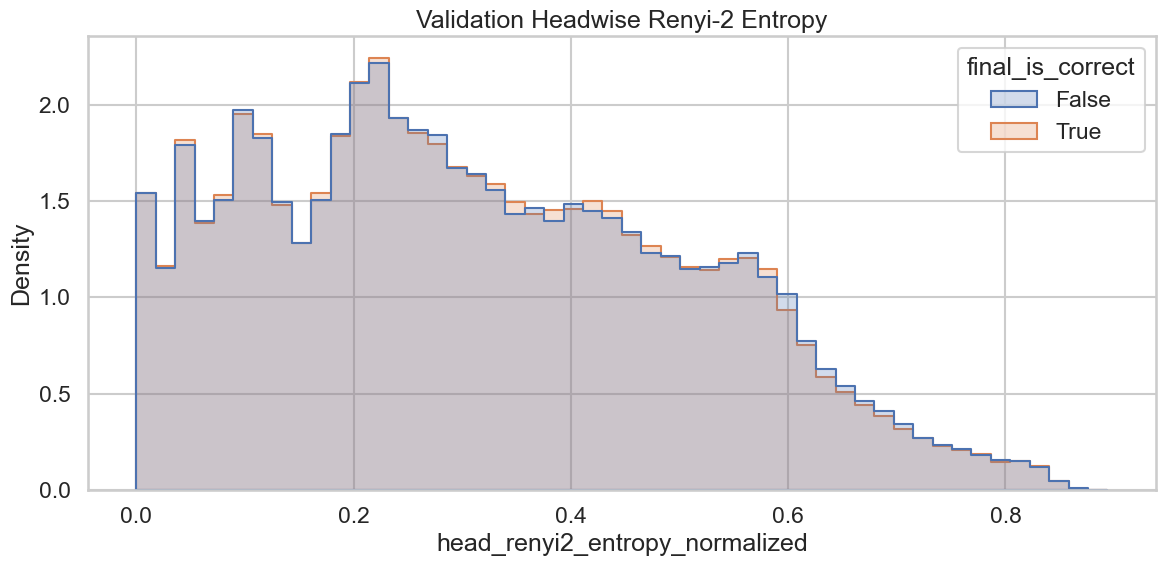

In [14]:
validation_head_df = headwise_feat_df.loc[headwise_feat_df['split'].eq('validation')].copy()

display(
    validation_head_df.groupby('final_is_correct', as_index=False)
    .agg(mean_head_renyi2_entropy=('head_renyi2_entropy_normalized', 'mean'))
    .round(4)
)

plt.figure(figsize=(12, 6))
sns.histplot(
    data=validation_head_df,
    x='head_renyi2_entropy_normalized',
    hue='final_is_correct',
    stat='density',
    common_norm=False,
    bins=50,
    element='step'
)
plt.title('Validation Headwise Renyi-2 Entropy')
plt.tight_layout()
plt.show()


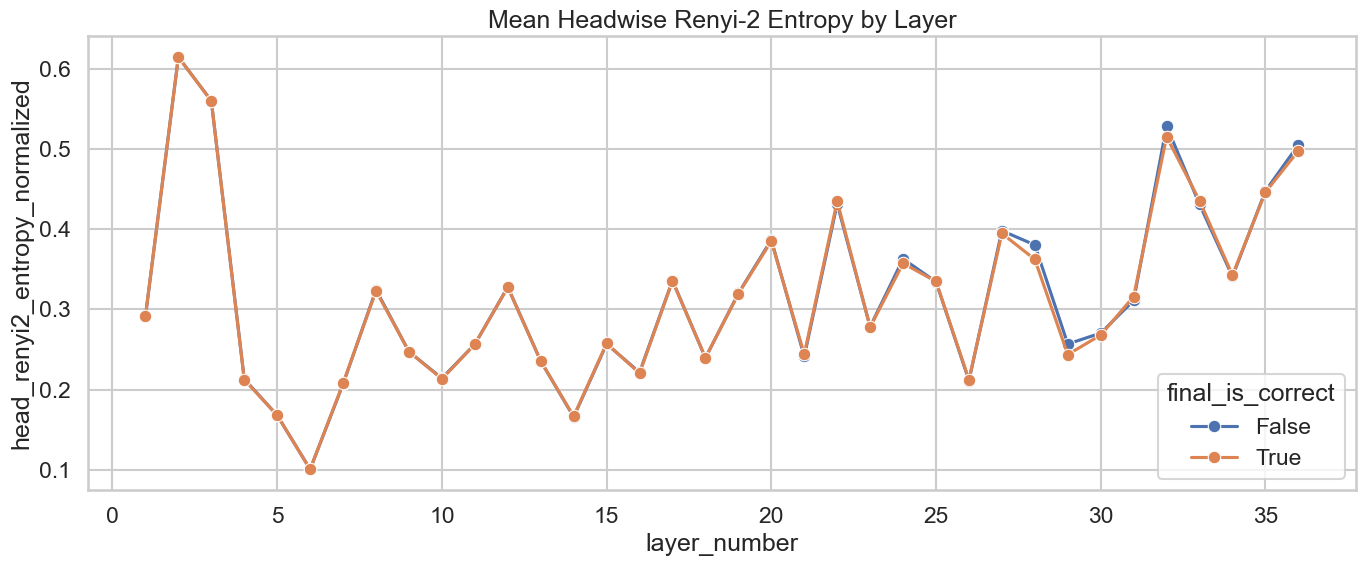

In [15]:
head_layer_mean_df = (
    validation_head_df.groupby(['layer_number', 'final_is_correct'], as_index=False)['head_renyi2_entropy_normalized']
    .mean()
)

plt.figure(figsize=(14, 6))
sns.lineplot(data=head_layer_mean_df, x='layer_number', y='head_renyi2_entropy_normalized', hue='final_is_correct', marker='o')
plt.title('Mean Headwise Renyi-2 Entropy by Layer')
plt.tight_layout()
plt.show()


## Headwise Predictive Strength

In [16]:
head_auc_rows = []
for (layer_number, head_number), part in validation_head_df.groupby(['layer_number', 'head_number']):
    y = part['final_error'].to_numpy(dtype=int)
    score = -part['head_renyi2_entropy_normalized'].to_numpy(dtype=float)
    head_auc_rows.append({
        'layer_number': int(layer_number),
        'head_number': int(head_number),
        'roc_auc_error': float(roc_auc_score(y, score)),
        'pr_auc_error': float(average_precision_score(y, score)),
    })
head_auc_df = pd.DataFrame(head_auc_rows)

display(head_auc_df.sort_values(['pr_auc_error', 'roc_auc_error'], ascending=False).head(20).round(4))


,layer_number,head_number,roc_auc_error,pr_auc_error
558,35,15,0.5650,0.2948
482,31,3,0.6213,0.2877
492,31,13,0.6204,0.2719
476,30,13,0.5911,0.2691
450,29,3,0.5738,0.2612
491,31,12,0.5447,0.2584
512,33,1,0.5863,0.2533
489,31,10,0.6016,0.2476
556,35,13,0.5300,0.2442
426,27,11,0.5431,0.2408


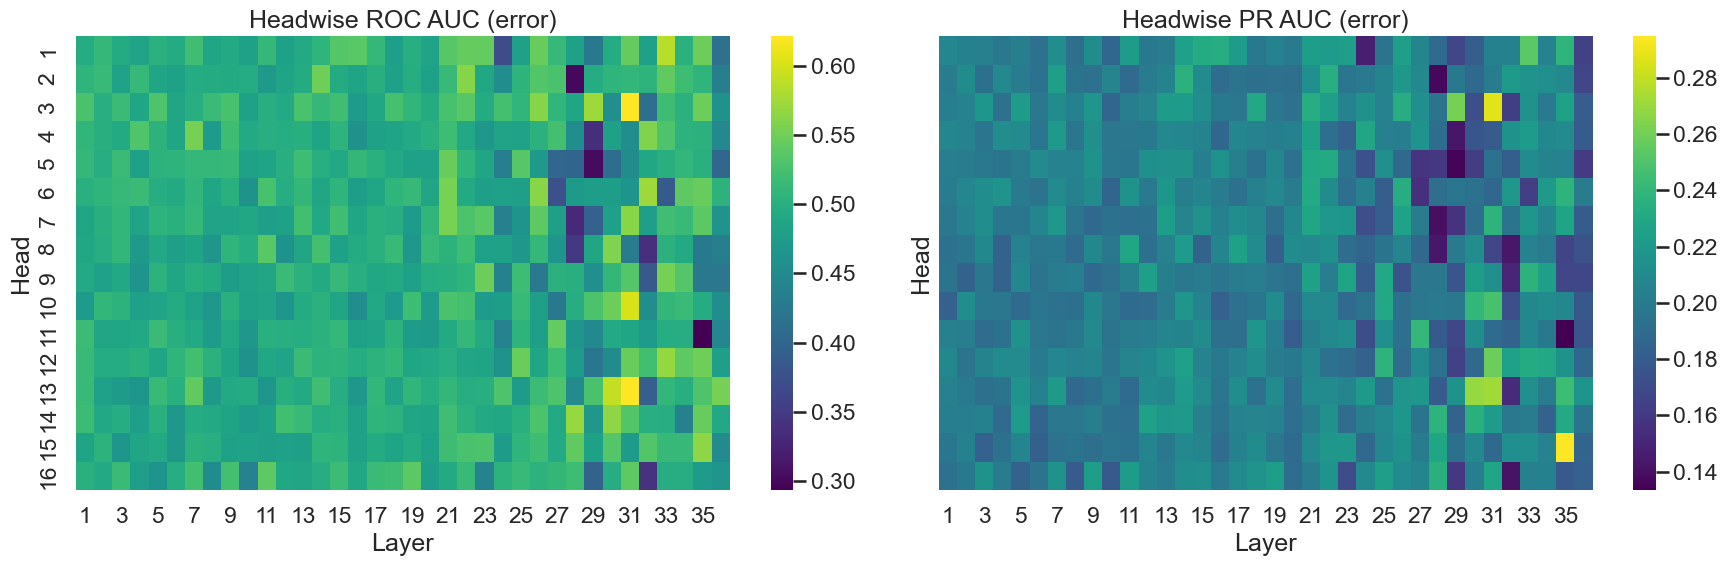

In [17]:
roc_pivot = head_auc_df.pivot(index='head_number', columns='layer_number', values='roc_auc_error')
pr_pivot = head_auc_df.pivot(index='head_number', columns='layer_number', values='pr_auc_error')

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
sns.heatmap(roc_pivot, cmap='viridis', ax=axes[0])
axes[0].set_title('Headwise ROC AUC (error)')
axes[0].set_xlabel('Layer')
axes[0].set_ylabel('Head')

sns.heatmap(pr_pivot, cmap='viridis', ax=axes[1])
axes[1].set_title('Headwise PR AUC (error)')
axes[1].set_xlabel('Layer')
axes[1].set_ylabel('Head')
plt.tight_layout()
plt.show()


## Useful Top Tables

In [18]:
best_layerwise_pr = (
    layer_auc_df.sort_values(['pr_auc_error', 'roc_auc_error'], ascending=False)
    .groupby(['feature', 'readout_method'], as_index=False)
    .head(3)
)
display(best_layerwise_pr.round(4))

best_heads = head_auc_df.sort_values(['pr_auc_error', 'roc_auc_error'], ascending=False).head(25)
display(best_heads.round(4))


,readout_method,layer_number,feature,roc_auc_error,pr_auc_error
170,direct_readout,35,answer_choice_entropy_normalized,0.7791,0.4732
178,direct_readout,36,choice_top1_probability,0.7820,0.4728
175,direct_readout,36,answer_choice_entropy_normalized,0.7820,0.4713
165,direct_readout,34,answer_choice_entropy_normalized,0.7735,0.4687
355,tuned_lens,36,answer_choice_entropy_normalized,0.7766,0.4663
168,direct_readout,34,choice_top1_probability,0.7739,0.4654
173,direct_readout,35,choice_top1_probability,0.7784,0.4642
176,direct_readout,36,answer_choice_top1_top2_logit_gap,0.7829,0.4617
171,direct_readout,35,answer_choice_top1_top2_logit_gap,0.7790,0.4554
358,tuned_lens,36,choice_top1_probability,0.7763,0.4524


,layer_number,head_number,roc_auc_error,pr_auc_error
558,35,15,0.5650,0.2948
482,31,3,0.6213,0.2877
492,31,13,0.6204,0.2719
476,30,13,0.5911,0.2691
450,29,3,0.5738,0.2612
491,31,12,0.5447,0.2584
512,33,1,0.5863,0.2533
489,31,10,0.6016,0.2476
556,35,13,0.5300,0.2442
426,27,11,0.5431,0.2408
